In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Scaling Laws and Current Transformer Configurations

The models in this chapter use the same blocks and training objectives as
much larger deployed models, but differ greatly in parameter count, data,
and computation. that section studied how hyperparameters transfer
between model sizes. Here we instead ask how performance changes with scale
and how a fixed training budget should be allocated between parameters and
data. We derive the $6ND$ approximation for training cost and compare it with
a profiler, conduct a small scaling experiment on one GPU, and summarize
the configurations reported for several 2023--2025 open-weight models.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import time
import torch
from torch.nn import functional as F
from torch.profiler import ProfilerActivity, profile

## Counting Parameters and FLOPs

### Counting Parameters

A GPT holds two kinds of parameters, and they scale differently. The
blocks hold $12d^2$ each — $4d^2$ of attention, $8d^2$ of feed-forward
network, however the activation slices it
(that section) — for about $12Ld^2$ across $L$ blocks.
The embedding holds $Vd$ for a vocabulary of size $V$, used twice thanks
to weight tying but stored once; a learned position table adds another
$\textrm{max\_len} \times d$. The census below runs the accounting on our
default configuration and on the GPT-2 configuration from
that section:

In [2]:
count = lambda m: sum(p.numel() for p in m.parameters())

def census(model, d, num_blks):
    emb = count(model.token_emb) + (
        count(model.pos_emb) if model.pos == 'learned' else 0)
    total = count(model)
    print(f'embedding {emb / 1e6:6.2f}M ({emb / total:4.0%}),  '
          f'blocks {(total - emb) / 1e6:6.2f}M '
          f'= {(total - emb) / (num_blks * d ** 2):.2f} L d^2,  '
          f'total {total / 1e6:.2f}M')

census(d2l.GPT(vocab_size=28), d=256, num_blks=6)
census(d2l.GPT(vocab_size=50257, num_hiddens=768, num_heads=12,
               num_blks=12, pos='learned', norm='layer', act='gelu',
               bias=True), d=768, num_blks=12)

embedding   0.01M (  0%),  blocks   4.72M = 12.01 L d^2,  total 4.73M


embedding  39.38M ( 32%),  blocks  85.06M = 12.02 L d^2,  total 124.44M


Both rows confirm the $12Ld^2$ rule to a fraction of a percent (the
residue is normalization weights and, for GPT-2, biases). The interesting
column is the embedding share: negligible for our character model with its
28 symbols, but nearly a third of GPT-2. Comparing $Vd$ against $12Ld^2$
says the embedding dominates when $V \gtrsim 12Ld$ — small models with
real vocabularies. GPT-2's "124M parameters" is in this sense a generous
description of an 85M-parameter transformer attached to a 39M-parameter
lookup table. Scaling-law papers accordingly count *non-embedding*
parameters [@kaplan2020scaling]: the embedding's size tracks the
tokenizer's vocabulary, not the computation each token receives, and
including it bends the low-end of every curve for accounting reasons
rather than scientific ones. We adopt the same convention; $N$ below means
non-embedding parameters.

### Six FLOPs per Parameter and Token

The approximation below counts matrix multiplications whose arithmetic scales
with the model parameters. It excludes attention-score and value-mixing
operations, which depend on context length even though they add no parameters.
For a context of $n$ tokens, those operations add about $4nd$ FLOPs per token
per layer, compared with approximately $24d^2$ from the block's linear maps.
The omitted-to-counted ratio is therefore about $n/(6d)$: 8% at $n=128$ and
$d=256$, and no longer small when $n$ approaches $6d$.

Multiplying one token's
activation vector by a weight matrix $\mathbf{W} \in \mathbb{R}^{m \times
n}$ takes $mn$ multiply–add pairs: 2 FLOPs per parameter, so a forward
pass costs about $2N$ per token. The backward pass costs twice the
forward: each linear layer must produce *two* gradients, one with respect
to its input ($\mathbf{W}^\top \boldsymbol{\delta}$, to keep the chain
rule moving) and one with respect to its weights ($\boldsymbol{\delta}
\mathbf{x}^\top$, to learn), and each is a matrix multiply of the same
size as the forward one. Training on $D$ tokens therefore costs

$$
C \approx \underbrace{2ND}_{\textrm{forward}} +
\underbrace{4ND}_{\textrm{backward}} = 6ND
$$

floating-point operations [@kaplan2020scaling]. This is training
arithmetic; the corresponding decode-time accounting — why *generating* a
token costs about $2N$ and why the KV cache turns generation into a
memory problem rather than a compute one — was the business of
that section.

Normalization, softmax, and optimizer updates add further operations not
represented by $6ND$. Thus the formula is a leading estimate for dense
transformers in the regime $n\ll6d$, not an exact operation count. It places
the teaching run of that section near $5\times10^{14}$ FLOPs under this
accounting convention; profiler comparisons below quantify the discrepancy.

### Checking the Arithmetic

We compare the approximation with framework operation counts.

PyTorch's profiler attributes FLOPs to the operations it recognizes —
above all the `aten::mm` matrix multiplies behind every linear layer. The
fused attention kernel keeps its score arithmetic to itself and reports
none, so the profiler and the equation ignore the *same* subleading
term. For the count, $N$ plus the tied output head is exactly the 2-D
parameters of the RoPE configuration. The embedding participates in matrix
multiplication as the head, whereas the lookup itself contributes no
counted FLOPs.

In [3]:
device = d2l.try_gpu()
model = d2l.GPT(vocab_size=28).to(device)
X = torch.randint(0, 28, (64, 128), device=device)
Y = torch.randint(0, 28, (64, 128), device=device)
N = sum(p.numel() for p in model.parameters() if p.ndim == 2)

def train_step():
    loss = F.cross_entropy(model(X).flatten(0, 1), Y.flatten())
    model.zero_grad()
    loss.backward()

for _ in range(3):
    train_step()                    # warm up
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
             with_flops=True) as prof:
    train_step()
measured = sum(e.flops for e in prof.key_averages() if e.flops)
print(f'6ND analytic: {6 * N * X.numel():.3e} FLOPs')
print(f'profiler:     {measured:.3e} FLOPs '
      f'(ratio {measured / (6 * N * X.numel()):.3f})')
if device.type == 'cuda':
    torch.cuda.synchronize()
t0 = time.time()
for _ in range(20):
    train_step()
if device.type == 'cuda':
    torch.cuda.synchronize()
dt = (time.time() - t0) / 20
print(f'{dt * 1e3:.0f} ms per step: '
      f'{6 * N * X.numel() / dt / 1e12:.1f} TFLOP/s achieved')

6ND analytic: 2.324e+11 FLOPs
profiler:     2.326e+11 FLOPs (ratio 1.001)


21 ms per step: 11.0 TFLOP/s achieved


Both authorities side with the formula. The PyTorch profiler's count
agrees with $6ND$ to a fraction of a percent — matching so tightly only
because both books omit the fused attention kernel's score work. XLA's
static analysis, which counts everything, lands about ten percent above
$6ND$, right where the $n/(6d)$ correction plus softmax and normalization
put it, and splits forward to backward at almost exactly one to two: the
derivation's 2-plus-4, read off a compiler's ledger. The timing line adds
a practical limitation: our achieved throughput is roughly an order of magnitude
below what the GPU can deliver, because a model this small cannot keep
the hardware fully utilized. Production runs choose widths and batch sizes
to increase utilization, which favors larger matrix operations.

## A Miniature Scaling Study

Counting determines the cost of a run but not its resulting performance.
A *scaling law* describes the empirical regularity that
budgets are planned: across many orders of magnitude, language-model loss
falls as a power law in each of model size, data, and compute, provided
none of the three is the bottleneck [@kaplan2020scaling]. On log-log
axes a power law is a straight line. Within a validated regime, fitted lines
can support compute planning; extrapolation beyond that regime requires new
evidence. The Chinchilla study asked how to split a fixed
compute budget between $N$ and $D$. Under its model family, data mixture,
optimizer, and FLOP accounting, the fitted allocation grew parameters and
tokens at similar rates and placed the optimum near twenty training tokens per
parameter [@hoffmann2022training]. Its 70B-parameter model, trained on
1.4 trillion tokens, outperformed the study's 280B-parameter comparison
trained on 300 billion tokens at matched estimated compute. The ratio and
ranking are results of that protocol rather than universal constants.

The following fixed-data experiment illustrates a possible departure from a
straight log--log trend. It does not reproduce the Chinchilla fit.

### Constructing the Training Corpus

that section already showed what a too-small corpus does: 4.7M
parameters against 180 KB of Wells bottomed out their validation loss
within a few hundred steps and spent the rest of the run memorizing. Our
own preliminary check confirms the diagnosis for the whole size range: on
*The Time Machine* alone, every configuration beyond about $10^5$
parameters is saturated more or less immediately. A scaling study needs a
corpus large enough to distinguish the configurations. We use the Penn Treebank
training text (5 MB of Wall Street Journal prose that
that section uses for word vectors) concatenated onto the
novel. The subclass below reuses the entire character pipeline of
`d2l.TimeMachine` and changes two things: `_download` returns the
concatenated text, and the windows stride by `num_steps` instead of
overlapping (five million overlapping windows would be a five-gigabyte
tensor for no statistical gain). One cosmetic note: PTB ships
pre-tokenized, with rare words replaced by `<unk>` and numbers by `N`,
which the character pipeline renders as the literal words *unk* and *n* —
harmless static for a character model.

In [4]:
class ScalingCorpus(d2l.TimeMachine):
    """Character corpus: The Time Machine plus the PTB training text."""
    def _download(self):
        data_dir = d2l.download_extract('ptb')
        with open(f'{data_dir}/ptb.train.txt') as f:
            ptb = f.read()
        return super()._download() + ' ' + ptb

    def __init__(self, batch_size, num_steps, num_val=2000):
        d2l.DataModule.__init__(self)
        self.save_hyperparameters()
        corpus, self.vocab = self.build(self._download())
        array = d2l.tensor([corpus[i:i + num_steps + 1] for i in
                            range(0, len(corpus) - num_steps, num_steps)])
        self.X, self.Y = array[:, :-1], array[:, 1:]
        self.num_train = len(array) - num_val

data = ScalingCorpus(batch_size=64, num_steps=128)
print(f'{len(data.X) * 128 / 1e6:.1f}M characters in {len(data.X)} '
      f'windows, vocabulary size {len(data.vocab)}')

5.1M characters in 39491 windows, vocabulary size 28


The 5.1-million-character corpus is small enough to expose repeated-data
effects within a short experiment. We compare non-embedding parameter counts
from 0.33M to 14.2M while holding token exposure fixed. This range is chosen to
show where validation improvements may diminish; it is not derived from a
universal tokens-per-parameter rule.

### Comparing Five Model Sizes

The design: hold the data fixed and move only the model. Five sizes of
`d2l.GPT`, widths 96 to 384 and depths 3 to 8 grown together the way real
model families grow, spanning 0.33M to 14.2M non-embedding parameters —
about a factor of forty. Every size consumes an identical diet of 16.4M
tokens (2,000 steps of 64 sequences of 128 characters), roughly three
passes over the corpus. Dropout is zero: it was a small-corpus crutch in
that section, this experiment is *about* the corpus running out, and
the recipe table below will show that models whose corpora outweigh their
parameters do not use it either. The one hyperparameter that must not be
held fixed is the learning rate: that section showed that the
tuned optimum drifts with width, and a rate frozen at any single value
would handicap one end of the family (our pilot grid confirmed it at
both ends). We apply that section's transfer rule instead of re-tuning:
anchor at $10^{-3}$ for width 256 and scale inversely with width. One
seeded run per size; rerunning a point with a different seed moves it by
less than a hundredth of a nat, well below the structure we are about to
read.

In [5]:
def val_loss(model, data):
    model.to(device).eval()
    with torch.no_grad():
        losses = [F.cross_entropy(
            model(X.to(device)).flatten(0, 1), Y.to(device).flatten())
            for X, Y in data.val_dataloader()]
    model.train()
    return sum(l.item() for l in losses) / len(losses)

sizes = ((96, 3, 4), (128, 3, 4), (192, 4, 6), (256, 6, 8), (384, 8, 8))
Ns, curves = [], {'train': [], 'validation': []}
for d, num_blks, num_heads in sizes:
    torch.manual_seed(0)
    model = d2l.GPT(len(data.vocab), num_hiddens=d, num_heads=num_heads,
                    num_blks=num_blks, dropout=0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3 * 256 / d,
                                  weight_decay=0.0)
    losses = d2l.train_lm(model, data, optimizer, 2000)
    Ns.append(count(model) - count(model.token_emb))
    curves['train'].append(sum(losses[-50:]) / 50)
    curves['validation'].append(val_loss(model, data))
    print(f'd={d:3d}, {num_blks} blocks: {Ns[-1] / 1e6:5.2f}M parameters, '
          f'train {curves["train"][-1]:.2f}, '
          f'validation {curves["validation"][-1]:.2f}')

d= 96, 3 blocks:  0.33M parameters, train 1.21, validation 1.20


d=128, 3 blocks:  0.59M parameters, train 1.17, validation 1.17


d=192, 4 blocks:  1.77M parameters, train 1.11, validation 1.12


d=256, 6 blocks:  4.72M parameters, train 1.06, validation 1.09


d=384, 8 blocks: 14.16M parameters, train 1.03, validation 1.06


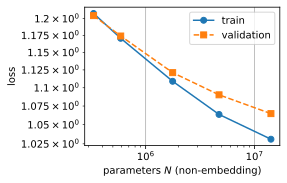

In [6]:
d2l.plot(Ns, [curves['train'], curves['validation']],
         'parameters $N$ (non-embedding)', 'loss',
         legend=['train', 'validation'], xscale='log', yscale='log',
         fmts=('o-', 's--'))

### Interpreting the Departure from a Power Law

The smaller models lie approximately along a straight segment on the log--log
plot. The largest model shows a smaller validation improvement than an
extrapolation from that segment, while its training loss continues to fall.
This widening train--validation gap is consistent with a fixed-data
limitation after three passes through the 5.1-million-character corpus. Other
explanations, including model-specific optimization and hyperparameter
effects, are not excluded by this sweep.

This five-size, one-seed experiment is a qualitative demonstration of how a
fixed corpus can limit gains from additional parameters. It cannot estimate a
power-law exponent, an irreducible loss, or a compute-optimal token--parameter
ratio. Those quantities in the next subsection come from the multi-model,
multi-data fits of @kaplan2020scaling; @hoffmann2022training, not from
our curve. Repeated-data studies further show that the value of additional
passes depends on repetition count and data conditions
[@Muennighoff.Rush.Barak.ea.2023].

Two footnotes before trusting the plot. First, a scaling study is only as
good as the tuning of each point: had we frozen the learning rate across
widths, part of our "bend" would have been a tuning artifact
(that section; exercise 5 has you produce this artifact
deliberately). Second, loss is the quantity that scales smoothly;
downstream abilities can surface abruptly as loss creeps down, which is
why small differences on this axis are worth more than they look
[@wei2022emergent].

### The Published Form of the Law

Our miniature moved $N$ with $D$ pinned; the published fits treat both as
free variables. Across more than four hundred training runs,
@hoffmann2022training fit the loss surface

$$
L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}},
$$

Here $E$ is a fitted asymptotic floor under the study's data distribution and
loss definition; $A/N^{\alpha}$ and $B/D^{\beta}$ describe fitted parameter-
and data-limited contributions. With $D$ fixed, the latter two terms predict
diminishing gains from increasing $N$. This is qualitatively consistent with
our largest-model result, but our five points do not identify any of the
terms or show that this law caused the observed bend.

Compute-optimal allocation drops out of the equation with
one constraint. Fix a budget $C \approx 6ND$, substitute $D = C/6N$, and
set the derivative in $N$ to zero: the optimum satisfies

$$
\alpha \frac{A}{N^{\alpha}} = \beta \frac{B}{D^{\beta}},
$$

i.e., spend until the two shrinkable terms are shrinking at equal
marginal rates. Solving gives $N^* \propto C^{\beta/(\alpha+\beta)}$ and
$D^* \propto C^{\alpha/(\alpha+\beta)}$. The fitted exponents come out
nearly equal ($\alpha \approx 0.34$, $\beta \approx 0.28$), so both
optima scale close to $C^{1/2}$: parameters and tokens should grow in
near-lockstep. In the models, data mixture, optimizer, and FLOP accounting of
@hoffmann2022training, the fitted allocation was approximately twenty
training tokens per parameter. This is a result for that protocol, not a
portable constant; data quality, repeated data, model family, and accounting
conventions can shift the allocation. We do not fit $E$, $\alpha$, $\beta$ to our own five points (the
previous subsection said why); what the miniature contributes is the
shape of both terms — the straight stretch is $A/N^{\alpha}$ falling
while the data term is negligible, and the bend is the crossover where
the fixed corpus's $B/D^{\beta}$ takes over.

## Reported Transformer Configurations, 2023--2025

Architectural reports for large training runs can be compared along the
interfaces developed in this chapter. the table compiles
the architecture sections of seven
open-weights families onto the axes this chapter built: Mistral 7B
[@Jiang.Sablayrolles.Mensch.ea.2023], Llama 3
[@Grattafiori.Dubey.Jauhri.ea.2024], Qwen3
[@Yang.Li.Yang.ea.2025], OLMo 2 and 3 [@OLMo.2025; @OLMo3.2025],
DeepSeek-V3 [@Liu.Feng.Xue.ea.2024], Gemma 3
[@Gemma.Team.2025], and GPT-OSS [@OpenAI.2025].

### Common Architectural Choices

<!-- tbl-caption:The 2023–2025 open-weights recipe, one row per model family. Attention and cache column: that section. Normalization: that section. Positions: that section. Mixture of experts: that section. -->

| model | attention and cache | normalization | positions | FFN | dense or MoE | dropout |
|:--|:--|:--|:--|:--|:--|:--|
| Mistral 7B (2023) | GQA $32{:}8$; sliding window 4096 | RMSNorm, pre | RoPE, $\theta = 10^4$ | SwiGLU | dense | none |
| Llama 3 (2024) | GQA $32{:}8$ | RMSNorm, pre | RoPE, $\theta = 5 \times 10^5$ | SwiGLU | dense | none |
| Qwen3 (2025) | GQA: $64{:}8$ dense (32B), $64{:}4$ MoE (235B-A22B) | RMSNorm, pre; QK-norm | RoPE, $\theta = 10^6$; YaRN for long context | SwiGLU | dense, and MoE: 128 experts, 8 active | none |
| OLMo 2/3 (2024/25) | MHA (7B), GQA (32B); OLMo 3: window 4096 on 3 of 4 layers | RMSNorm, post but off-stream; QK-norm | RoPE | SwiGLU | dense | none |
| DeepSeek-V3 (2024) | MLA: KV compressed to a 512-dim latent | RMSNorm, pre | RoPE on a decoupled 64-dim slice per head | SwiGLU | MoE: 256 experts plus 1 shared, 8 active | none |
| Gemma 3 (2025) | GQA; local:global $5{:}1$, window 1024 | RMSNorm, pre and post; QK-norm | RoPE, $\theta = 10^6$ global, $10^4$ local | GeGLU | dense | none |
| GPT-OSS (2025) | GQA $64{:}8$; window 128 on alternate layers; learned sinks | RMSNorm, pre | RoPE; YaRN | SwiGLU, clamped | MoE: 128 or 32 experts, 4 active | none |

Read down the columns and the convergence is hard to miss. Every row is
the block of that section in the causal wiring of
that section; nothing here is a new architecture in the sense that
the transformer was new against the LSTM. The differences cluster on
exactly three axes. *Stability*: where the norms sit and what they
normalize, with pre-norm almost everywhere, RMSNorm everywhere, QK-norm
spreading through the 2025 column (OLMo's post-but-off-stream placement
is the one live dissent, and it concedes the residual stream's identity
path, the actual lesson of our signal-propagation experiment). *The
cache*: GQA as the default, with the window-plus-sink and latent
compressions of that section where long contexts make the
cache the binding cost. *Capacity per FLOP*: gated FFNs in every row, and
mixture of experts (that section) where the budget wants more
parameters than FLOPs. The dropout column also follows from the scaling
regime: at trillion-token scale the corpus outweighs the parameters,
overfitting is not the failure mode, and the regularizer used in
that section is omitted. Even the
positions column is one idea at different dial settings: RoPE with an
inflated base for longer contexts, stretched further by interpolation
schemes (that section); the newest twist is still
a setting of the same dial, dropping positions entirely on some layers as
Llama 4's NoPE-interleaved long-context layers do.

### Expressing Configurations as Constructor Calls

that section represented architectural choices as constructor
arguments. At width 256 and six
blocks — here are four rows of the table as configurations of `d2l.GPT`,
with grouped-query attention dropped in through the same seam
that section built:

In [7]:
recipes = {
    'GPT-2 (2019)': dict(pos='learned', norm='layer', act='gelu',
                         pre_norm=True, bias=True, kv_heads=8),
    'Mistral-7B':   dict(pos='rope', norm='rms', act='swiglu',
                         pre_norm=True, bias=False, kv_heads=2),
    'Llama-3':      dict(pos='rope', norm='rms', act='swiglu',
                         pre_norm=True, bias=False, kv_heads=2),
    'Qwen3':        dict(pos='rope', norm='rms', act='swiglu',
                         pre_norm=True, bias=False, kv_heads=2),
}
for name, cfg in recipes.items():
    kv_heads = cfg.pop('kv_heads')
    model = d2l.GPT(vocab_size=1024, num_hiddens=256, num_heads=8,
                    num_blks=6, **cfg)
    if kv_heads < 8:            # grouped-query attention, as deployed
        for blk in model.blks:
            blk.attention = d2l.GQAAttention(
                256, 8, kv_heads, rope=(cfg['pos'] == 'rope'))
    d2l.check_shape(model(torch.zeros(2, 16, dtype=torch.long)),
                    (2, 16, 1024))
    print(f'{name:12s} {count(model) / 1e6:.2f}M  '
          + ', '.join(f'{k}={v!r}' for k, v in cfg.items())
          + f', kv_heads={kv_heads}')

GPT-2 (2019) 5.26M  pos='learned', norm='layer', act='gelu', pre_norm=True, bias=True, kv_heads=8
Mistral-7B   4.40M  pos='rope', norm='rms', act='swiglu', pre_norm=True, bias=False, kv_heads=2
Llama-3      4.40M  pos='rope', norm='rms', act='swiglu', pre_norm=True, bias=False, kv_heads=2
Qwen3        4.40M  pos='rope', norm='rms', act='swiglu', pre_norm=True, bias=False, kv_heads=2


The three modern rows print the *same argument list*. At the resolution of
our constructor, these configurations share one recipe,
and what distinguishes deployed families lives in the columns the flags
do not reach: window widths, RoPE bases, expert counts, and the
normalization refinements we left as exercises (QK-norm slots in through
`attn_factory`, as in that section's exercises). The
two rows we did not instantiate are the two seams working as designed:
DeepSeek's MLA is the low-rank cache compression whose miniature
that section trained, and every MoE cell in the table swaps the
FFN through `ffn_factory` for the expert layer of that section.
The configurations share solutions to three requirements: stable training,
limited decode-time memory, and high capacity per FLOP. They retain the
basic 2017 transformer block while changing normalization, attention, and
feed-forward components to address these requirements.

## Reported Extensions, 2023--2025

Three directions extend the material in this chapter. First, models reduce
the attention layer's quadratic cost (that section). The sliding-window rows of
the table are the mild form, and the stronger form
replaces most attention layers outright with the linear-time recurrent
mixers of that section, keeping full attention in only a
fraction of layers. These hybrids perform exact global lookup only in
selected layers; that section examines the resulting tradeoffs.
Second, long context has become an
engineering discipline of its own: the number in a model card is a
compound of RoPE base inflation and interpolation
(that section), window-and-sink cache policies
(that section), and the systems work of
that section. The architectural changes are settings of the attention layer this chapter
already built, and the rest is positional bookkeeping and systems
engineering. Third, further gains depend on choices held fixed in this
chapter: the training data and the procedures applied after pretraining.
Data curation, instruction tuning, and learning from feedback
are the subject of the Language Models part, beginning in
that section.

## Summary

For a transformer with $N \approx 12Ld^2$ non-embedding parameters trained
on $D$ tokens, the leading training cost is approximately $6ND$: two
floating-point operations per parameter and token in the forward pass and
four in the backward pass. Attention-score computation adds a correction
that remains smaller for the configurations studied here. PyTorch profiling
and XLA cost analysis confirm the approximation within a few percent. In
our five-size experiment with a fixed 5.1-million-character corpus, loss
initially follows a power law with model size and then departs from it as the
largest model becomes data-limited. The model
$L(N,D)=E+A N^{-\alpha}+B D^{-\beta}$ separates irreducible, parameter, and
data terms. Under $C\approx6ND$, compute-optimal training increases both
parameters and tokens. The Chinchilla study found approximately twenty tokens
per parameter under its model, data, optimizer, and compute conventions; this
ratio is not universal. The 2023--2025 configurations tabulated here commonly combine pre-norm and
RMSNorm with gated FFNs, RoPE, and GQA or latent-compressed attention; some
also use mixture-of-experts layers. These models differ mainly in their
settings of a shared collection of architectural components.

## Exercises

1. Derive the six in the equation for our default configuration
   exactly. Write the per-block matmul parameter count for width 256
   (fused QKV, output projection, and the three SwiGLU matrices), add the
   tied head, and multiply out $6ND$ for one batch. Compare against the
   profiler cell's analytic line. Then add the attention-score term: at
   what context length $n$ would the score work equal the linear-layer
   work for this width?
2. Run the Chinchilla sanity check on our study. At twenty tokens per
   parameter, how many tokens would each of our five sizes want, and how
   many *unique* characters does our corpus provide? Which sizes exceed
   the ratio, and how does that align with where the measured curve
   bends? Our budget shows each character about three times; using the
   findings of @Muennighoff.Rush.Barak.ea.2023, argue whether
   doubling the number of passes would rescue the largest model.
3. Add a row to the table. Pick an open-weights model
   this section does not cover — Kimi K2 [@Kimi.Team.2025] is a good
   subject — read the architecture section of its report, and fill in
   every column. Which cells map onto `d2l.GPT` constructor flags, which
   need the `attn_factory`/`ffn_factory` seams, and which would need
   machinery this chapter has not built?
4. The census showed GPT-2's embedding at roughly a third of its
   parameters. Derive the condition on $V$, $d$, and $L$ under which the
   embedding holds at least half of all parameters, and check it against
   GPT-2's numbers. Why do scaling-law fits improve when embedding
   parameters are excluded from $N$?
5. Rerun the sweep with the learning rate frozen at $10^{-3}$ for every
   size. Which points move, and in which direction? Explain each
   movement using the width-dependence of the tuned optimum from
   that section, and state what a naive reader of the resulting
   plot would conclude that the properly tuned plot does not support.
6. Extend the sweep one size upward: width 512, ten blocks, about 31M
   non-embedding parameters. Before running it, predict its validation
   loss twice — once by extending the straight line through the small
   sizes, once by assuming the corpus is fully saturated (no improvement
   over the largest measured size) — and estimate the run's cost in
   FLOPs via the equation. Then run it. Which prediction was
   closer, and what does the answer say about how much headroom three
   passes over 5.1M characters leave?